# Predicting the World Cup

This notebook implements a data-driven framework to simulate the 2026 FIFA World Cup. By integrating historical Elo ratings with a comprehensive dataset of international match results, it leverages an XGBoost classifier to predict match probabilities (Win, Draw, Loss).

## Run imports

In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import pickle
import collections
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data and Model

## Model input

---

 Feature | Description |
 --- | --- |
 elo_home | Elo rating of home team before match |
 elo_away | Elo rating of away team before match |
 elo_diff | elo_home − elo_away |
 is_neutral | 1 if neutral venue |
 match_type | friendly / qualifier / tournament |
 outcome | 0 = away win, 1 = draw, 2 = home win |


In [2]:
# Load current ELO rankings
current_elo_ratings = pd.read_csv("/kaggle/input/datasets/josephsatzl/predicting-the-2026-fifa-world-cup/current_elo_ratings.csv")

# Match type map: {0:friendly, 1:qualifier, 2:tournament}
match_type_map = pickle.load(open("/kaggle/input/datasets/josephsatzl/predicting-the-2026-fifa-world-cup/match_type_map.pkl", "rb"))

# Load groups
groups = pd.read_csv("/kaggle/input/datasets/josephsatzl/predicting-the-2026-fifa-world-cup/wc26_groups.csv")

# Load tournament tree
matches = pd.read_csv("/kaggle/input/datasets/josephsatzl/predicting-the-2026-fifa-world-cup/wc26_matches.csv")

# Load the trained model
model = xgb.XGBClassifier()
model.load_model("/kaggle/input/datasets/josephsatzl/predicting-the-2026-fifa-world-cup/model.json")

## Match Simulation

`predict_match(t1,t2,l,match_type)` predicts the outcome probabilities of a football match.

### Input
- t1: Country Code of the home team
- t2: Country Code of the away team
- l: is the Country code of the games host ('MX', 'US', 'CA')
- match_type: 0 is for friendlies, 1 is for qualifiers and 2 is for tournament
- draw=1: draws allowed, draw=0: draws exempt
- log=0: Dont log Match Results, log=1: Log results

### Output

probs[0] = P(Away)<br>
probs[1] = P(Draw)<br>
probs[2] = P(Home)<br>



In [3]:
def predict_match(t1, t2, l, match_type=2, draw=1, log=0): # draw=1 means that draws are allowed outcomes
    
    # Get ELOs and ELO diff
    elo_home = current_elo_ratings.loc[current_elo_ratings['Country_Code'] == t1, 'Elo_Rating'].values[0]
    elo_away = current_elo_ratings.loc[current_elo_ratings['Country_Code'] == t2, 'Elo_Rating'].values[0]
    #print(f"DEBUG: Looking up Elo for t1:'{t1}' = {elo_home}, and t2:'{t2}' = {elo_away}")
    elo_diff = elo_home - elo_away

    # Determine if Game is neutral
    # World Cup games are always neutral
    # Except for the hosts (USA, Canada and Mexico)
    if t1 == l or t2 == l:
        is_neutral = 0
    else:
        is_neutral = 1
    
    match_features = np.array([[elo_home, elo_away, elo_diff, is_neutral, match_type]])

    probs = model.predict_proba(match_features)[0]

    # If draws are not allowed, eliminate the outcome
    if draw==0:
        probs = np.array([probs[0], 0, probs[2]])

    probs /= probs.sum()

    if log==1:
        print(f"Match {t1}:{(round(probs[2], 2))*100} vs. {t2}:{(round(probs[0], 2))*100}, draw:{(round(probs[1], 2))*100}")
    
    return probs # probs[0] = away win prob, probs[1] ...

## Tournament Simulation

In [4]:
def get_group_standings(results):
    # Calculate Standings after Groupphase
    # structure: standings[group][team] = {stats}
    standings = collections.defaultdict(lambda: collections.defaultdict(lambda: {'pts': 0, 'w': 0, 'd': 0, 'l': 0, 'gp': 0}))

    for result in results:
        t1 = result[0]
        t2 = result[1]
        group = result[2]
        outcome = result[3] #.item() # or, .astype(int)
        
        # Update Games Played
        standings[group][t1]['gp'] += 1
        standings[group][t2]['gp'] += 1

        if outcome == 2: # Home Win (T1 wins)
            standings[group][t1]['pts'] += 3
            standings[group][t1]['w'] += 1
            standings[group][t2]['l'] += 1
        elif outcome == 1: # Draw
            standings[group][t1]['pts'] += 1
            standings[group][t2]['pts'] += 1
            standings[group][t1]['d'] += 1
            standings[group][t2]['d'] += 1
        else: # Away Win (T2 wins)
            standings[group][t2]['pts'] += 3
            standings[group][t2]['w'] += 1
            standings[group][t1]['l'] += 1

    # Convert to a sorted list for each group
    final_standings = {}
    for group, teams in standings.items():
        # Sort by Points (primary) and then Wins (secondary)
        sorted_teams = sorted(
            teams.items(), 
            key=lambda x: (x[1]['pts'], x[1]['w']), 
            reverse=True
        )
        final_standings[group] = sorted_teams

    #print(f'Final group standings: {final_standings}')
    return final_standings

In [5]:
def get_r32_mapping(standings):
    # Function to fill undetermined Round of 32 matches
    mapping = {}

    #1. Map Winners and Runners_Up
    for group in standings:
        mapping[f'W_Grp{group}'] = standings[group][0][0]
        mapping[f'RU_Grp{group}'] = standings[group][1][0]

    # Top 8 third place teams
    third_place_teams = []
    
    for group in standings:
        if len(standings[group]) > 2:
            # Save all third place games
            team_name, stats = standings[group][2]
            
            third_place_teams.append({
                'team': team_name,
                'group': group,
                'pts': stats['pts'],
                'w': stats['w']
            })
        else:
            print(f"Group {group} does not have a 3rd place team.")
            
    # Now sorted() will find 'pts' in every dictionary
    ranked_thirds = sorted(
        third_place_teams, 
        key=lambda x: (x['pts'], x['w']), 
        reverse=True
    )[:8]


    third_place_slots = [
        ('3rd_ABCDEF', ['A', 'B', 'C', 'D', 'F']),
        ('3rd_CDFGH',  ['C', 'D', 'F', 'G', 'H']),
        ('3rd_CEFHI',  ['C', 'E', 'F', 'H', 'I']),
        ('3rd_EHIJK',  ['E', 'H', 'I', 'J', 'K']),
        ('3rd_BEFIJ',  ['B', 'E', 'F', 'I', 'J']),
        ('3rd_AEHIJ',  ['A', 'E', 'H', 'I', 'J']),
        ('3rd_EFGIJ',  ['E', 'F', 'G', 'I', 'J']),
        ('3rd_DEIJL',  ['D', 'E', 'I', 'J', 'L'])
    ]

    used_teams = set()
    for placeholder, eligible_groups in third_place_slots:
        for t_info in ranked_thirds:
            if t_info['group'] in eligible_groups and t_info['team'] not in used_teams:
                mapping[placeholder] = t_info['team']
                used_teams.add(t_info['team'])
                break
            elif t_info['team'] not in used_teams:
                mapping[placeholder] = t_info['team']
                used_teams.add(t_info['team'])
                break

    #print(f"DEBUG: R32 mapping: {mapping}")
    return mapping

In [6]:
def simulate_tournament(log=0):
    results = [] # t1, t2, group, outcome, probabilities
    for match in matches.itertuples():
        # Predict Group Phase
        if match[6] == 'WC':
            # Get teams and Location
            t1 = match[4]
            t2 = match[5]
            l = match[7]

            # Get group
            g = groups.loc[groups['Country'] == t1, 'Group'].values[0]

            probs = predict_match(t1, t2, l, log=log)

            # Weighted choice of outcome
            o = [0, 1, 2] # 0 = away win, 1 = draw, 2 = home win
            outcome = np.random.choice(o, size=1, p=probs)

            results.append([t1, t2, g, outcome, probs])

        
        # Simulate Round of 32
        elif match[6] == 'WC_R32':
            # Get Standings and Mapping
            if match[8] == 73: #Query only on first R32 match
                standings = get_group_standings(results)
                team_map = get_r32_mapping(standings)
            # Find Team 1 and Team 2
            t1 = team_map.get(match[4], match[4])
            t2 = team_map.get(match[5], match[5])
            l = match[7]
            
            probs = predict_match(t1, t2, l, draw=0, log=log)

            # Weighted choice of outcome
            o = [0, 1, 2] # 0 = away win, 1 = draw, 2 = home win
            outcome = np.random.choice(o, size=1, p=probs)


            results.append([t1, t2, "R32", outcome, probs])

        else:
            def get_winner(match_str, results_list):
                # Extracts digits from strings like 'Winner_73'
                m_id = int(''.join(filter(str.isdigit, match_str)))
                # Adjust index: if match 73 is the 73rd item in 'results' -> m_id -1
                prev_match = results_list[m_id - 1] 
    
                # outcome 2 = t1 wins, outcome 0 = t2 wins, outcome 1 = draw (shouldn't happen here)
                return prev_match[0] if prev_match[3] == 2 else prev_match[1]

            t1 = get_winner(match[4], results)
            t2 = get_winner(match[5], results)

            # Exception for 3rd place game
            if match[8] == 103:
                # T1 is the away team if home team won
                if results[100][3] == 2:
                    t1 = results[100][1]
                else:
                    t1 = results[100][0]
                if results[101][3] == 2:
                    t2 = results[101][1]
                else:
                    t2 = results[101][0]

            l = match[7]

            probs = predict_match(t1, t2, l, draw=0, log=log)

            # Weighted choice of outcome
            o = [0, 1, 2] # 0 = away win, 1 = draw, 2 = home win
            outcome = np.random.choice(o, size=1, p=probs)

            results.append([t1, t2, match[6], outcome, probs]) # "R16" for Round of 16
    
    if results[-1][3] == 2:
        winner = results[-1][0]
    else:
        winner = results[-1][1]
    return results, winner

## Run Monte Carlo Simulations

In [7]:
def run_monte_carlo(n=10000):
    # Array of winners
    w = {}
    for i in tqdm(range(n)):
        results, winner = simulate_tournament() # log=1 for log option
        if w.get(winner) == None:
            w[winner] = {
                "n": 1,
                "prob": round((1/n)*100, 2)
            }
        else:
            w[winner]["n"] += 1
            w[winner]["prob"] = round(((w[winner]["n"])/n)*100, 2)

    # Sort dict
    w = dict(sorted(w.items(), key=lambda x: x[1]["prob"], reverse=True))
            
    return w

w = run_monte_carlo()
print(w)

100%|██████████| 10000/10000 [27:49<00:00,  5.99it/s]

{'ES': {'n': 2248, 'prob': 22.48}, 'AR': {'n': 1773, 'prob': 17.73}, 'FR': {'n': 1195, 'prob': 11.95}, 'EN': {'n': 709, 'prob': 7.09}, 'BR': {'n': 521, 'prob': 5.21}, 'CO': {'n': 474, 'prob': 4.74}, 'PT': {'n': 463, 'prob': 4.63}, 'NL': {'n': 363, 'prob': 3.63}, 'EC': {'n': 276, 'prob': 2.76}, 'HR': {'n': 263, 'prob': 2.63}, 'DE': {'n': 221, 'prob': 2.21}, 'TR': {'n': 177, 'prob': 1.77}, 'JP': {'n': 162, 'prob': 1.62}, 'NO': {'n': 157, 'prob': 1.57}, 'CH': {'n': 153, 'prob': 1.53}, 'MX': {'n': 151, 'prob': 1.51}, 'UY': {'n': 131, 'prob': 1.31}, 'BE': {'n': 128, 'prob': 1.28}, 'SN': {'n': 95, 'prob': 0.95}, 'PY': {'n': 72, 'prob': 0.72}, 'MA': {'n': 58, 'prob': 0.58}, 'CA': {'n': 54, 'prob': 0.54}, 'AT': {'n': 43, 'prob': 0.43}, 'AU': {'n': 22, 'prob': 0.22}, 'KR': {'n': 14, 'prob': 0.14}, 'SQ': {'n': 13, 'prob': 0.13}, 'IR': {'n': 12, 'prob': 0.12}, 'DZ': {'n': 11, 'prob': 0.11}, 'CZ': {'n': 8, 'prob': 0.08}, 'US': {'n': 8, 'prob': 0.08}, 'SE': {'n': 7, 'prob': 0.07}, 'PA': {'n': 6, 'p

## Visualizations



### Winner Team Probabilities

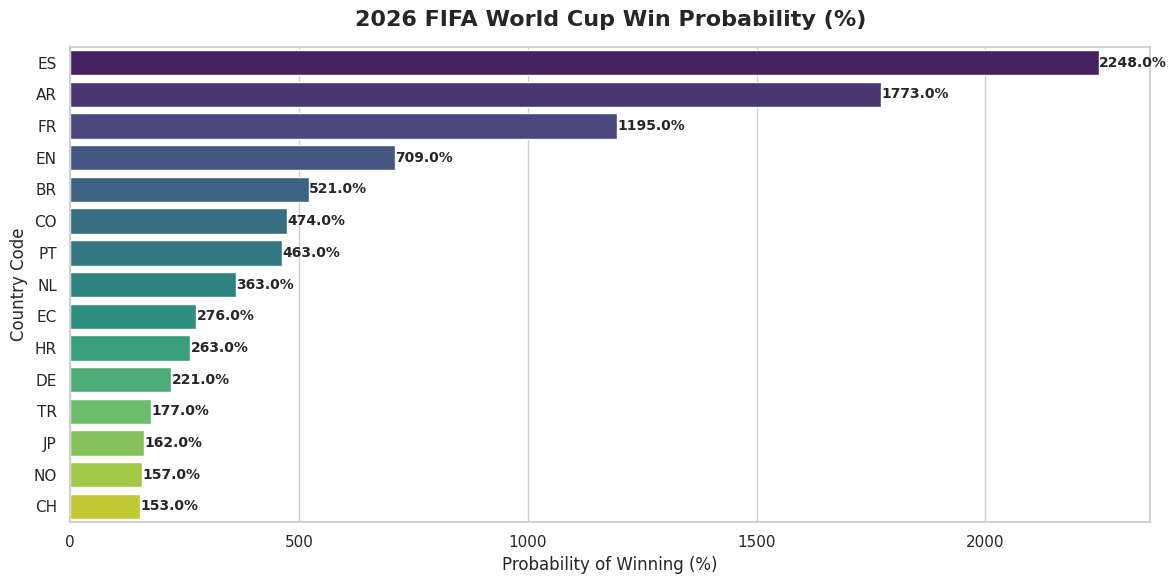

In [8]:
# Set style for a clean look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Extract top 15 teams for the visualization
top_n = 15
teams = list(w.keys())[:top_n]
probabilities = [w[team]['prob'] * 100 for team in teams] # Convert to percentage

# Create barplot
ax = sns.barplot(x=probabilities, y=teams, hue=teams, palette="viridis", legend=False)

# Add titles and labels
plt.title("2026 FIFA World Cup Win Probability (%)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Probability of Winning (%)", fontsize=12)
plt.ylabel("Country Code", fontsize=12)

# Annotate percentages on top of the bars
for i, p in enumerate(probabilities):
    ax.text(p + 0.3, i, f"{p:.1f}%", va='center', ha='left', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

### Feature Importance

The following visualization shows the importance of each feature in predicting the final outcome of a game.

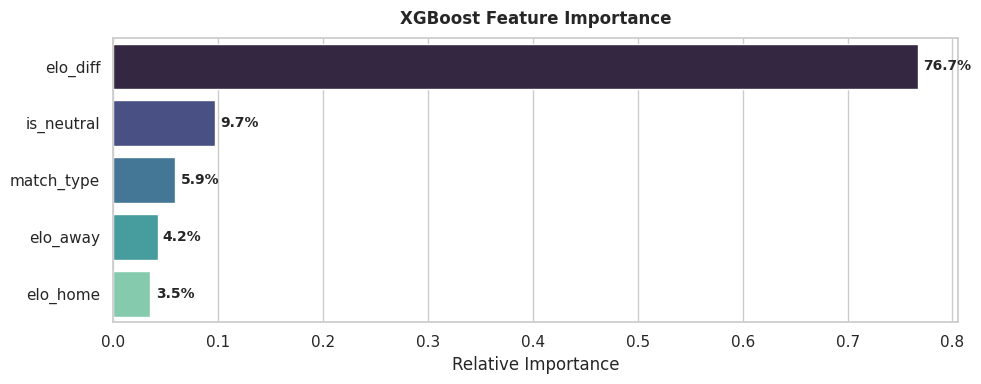

In [9]:
plt.figure(figsize=(10, 4))
features = ['elo_home', 'elo_away', 'elo_diff', 'is_neutral', 'match_type']
importances = model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

ax = sns.barplot(x=sorted_importances, y=sorted_features, hue=sorted_features, palette="mako", legend=False)
plt.title("XGBoost Feature Importance", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Relative Importance")

for i, p in enumerate(sorted_importances):
    ax.text(p + 0.005, i, f"{p*100:.1f}%", va='center', ha='left', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

## Export 

Export table with natioinal teams winning probabilities as winners.csv

In [10]:
output_path = "/kaggle/working/winners.csv"

# Extrakt only Key and Value
data_summary = [{'id': k, 'prob': v['prob']} for k, v in w.items()]

# Convert to DataFrame
df = pd.DataFrame(data_summary)

df.to_csv(output_path, index=False)